In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("Device:", device)

Device: cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True,
    download=True, transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False,
    download=True, transform=transform
)

100%|██████████| 170M/170M [00:04<00:00, 34.5MB/s] 


In [3]:
trainloader = DataLoader(trainset,
                         batch_size=128,
                         shuffle=True,
                         num_workers=2,
                         pin_memory=True)

testloader = DataLoader(testset,
                        batch_size=128,
                        shuffle=False,
                        num_workers=2,
                        pin_memory=True)

In [4]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return 100 * correct / total

def test_epoch(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

In [5]:
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,6,5),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(6,16,5),
            nn.ReLU(),
            nn.AvgPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*53*53,120),
            nn.ReLU(),
            nn.Linear(120,84),
            nn.ReLU(),
            nn.Linear(84,10)
        )

    def forward(self,x):
        return self.classifier(self.features(x))


model = LeNet5().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    train_acc = train_epoch(model, trainloader,
                            optimizer, criterion)
    print("Epoch", epoch+1, "Train:", train_acc)

test_acc = test_epoch(model, testloader)
print("LeNet Test Accuracy:", test_acc)

Epoch 1 Train: 42.108
Epoch 2 Train: 54.316
Epoch 3 Train: 61.792
LeNet Test Accuracy: 57.62


In [6]:
model = models.alexnet(
    weights=models.AlexNet_Weights.DEFAULT
)

model.classifier[6] = nn.Linear(4096,10)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    train_epoch(model, trainloader,
                optimizer, criterion)

print("AlexNet Test Accuracy:",
      test_epoch(model, testloader))

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 213MB/s] 


AlexNet Test Accuracy: 73.53


In [7]:
model = models.vgg16(
    weights=models.VGG16_Weights.DEFAULT
)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(4096,10)
model = model.to(device)

optimizer = optim.Adam(
    model.classifier.parameters(), lr=0.001
)

criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    train_epoch(model, trainloader,
                optimizer, criterion)

print("VGG Test Accuracy:",
      test_epoch(model, testloader))

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 227MB/s] 


VGG Test Accuracy: 85.84


In [8]:
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(2048,10)
model = model.to(device)

optimizer = optim.Adam(
    model.fc.parameters(), lr=0.001
)

criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    train_epoch(model, trainloader,
                optimizer, criterion)

print("ResNet50 Test Accuracy:",
      test_epoch(model, testloader))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


ResNet50 Test Accuracy: 80.68


In [9]:
model = models.resnet101(
    weights=models.ResNet101_Weights.DEFAULT
)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(2048,10)
model = model.to(device)

optimizer = optim.Adam(
    model.fc.parameters(), lr=0.001
)

criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    train_epoch(model, trainloader,
                optimizer, criterion)

print("ResNet101 Test Accuracy:",
      test_epoch(model, testloader))

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:00<00:00, 198MB/s] 


ResNet101 Test Accuracy: 84.59


In [10]:
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(1280,10)
model = model.to(device)

optimizer = optim.Adam(
    model.classifier.parameters(), lr=0.001
)

criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    train_epoch(model, trainloader,
                optimizer, criterion)

print("EfficientNet Test Accuracy:",
      test_epoch(model, testloader))

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 168MB/s]


EfficientNet Test Accuracy: 80.43


In [11]:
model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(1280,10)
model = model.to(device)

optimizer = optim.Adam(
    model.classifier.parameters(), lr=0.001
)

criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    train_epoch(model, trainloader,
                optimizer, criterion)

print("MobileNet Test Accuracy:",
      test_epoch(model, testloader))

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 145MB/s]


MobileNet Test Accuracy: 76.63


In [12]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss


class ArcFaceLoss(nn.Module):
    def __init__(self, scale=30):
        super().__init__()
        self.scale = scale
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, labels):
        logits = logits / torch.norm(logits, dim=1, keepdim=True)
        logits = logits * self.scale
        return self.ce(logits, labels)

In [13]:
model_vgg_bce = models.vgg16(
    weights=models.VGG16_Weights.DEFAULT
)

model_vgg_bce.classifier[6] = nn.Linear(4096, 10)
model_vgg_bce = model_vgg_bce.to(device)

optimizer = optim.Adam(
    model_vgg_bce.parameters(), lr=0.001
)

criterion = nn.BCEWithLogitsLoss()


def train_bce(model, loader):
    model.train()
    correct, total = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # Convert labels to one-hot
        y_onehot = torch.zeros(y.size(0), 10).to(device)
        y_onehot.scatter_(1, y.unsqueeze(1), 1)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y_onehot)
        loss.backward()
        optimizer.step()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return 100 * correct / total


for epoch in range(10):
    train_acc = train_bce(model_vgg_bce, trainloader)
    print("Epoch", epoch+1, "Train:", train_acc)

test_acc = test_epoch(model_vgg_bce, testloader)

print("VGG | Adam | BCE")
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Epoch 1 Train: 31.604
Epoch 2 Train: 56.666
Epoch 3 Train: 67.73
Epoch 4 Train: 73.15
Epoch 5 Train: 77.196
Epoch 6 Train: 80.354
Epoch 7 Train: 83.184
Epoch 8 Train: 85.772
Epoch 9 Train: 87.784
Epoch 10 Train: 89.476
VGG | Adam | BCE
Train Accuracy: 89.476
Test Accuracy: 78.94


In [14]:
model_alex_focal = models.alexnet(
    weights=models.AlexNet_Weights.DEFAULT
)

model_alex_focal.classifier[6] = nn.Linear(4096,10)
model_alex_focal = model_alex_focal.to(device)

optimizer = optim.SGD(
    model_alex_focal.parameters(), lr=0.01, momentum=0.9
)

criterion = FocalLoss(gamma=2)

for epoch in range(20):
    train_acc = train_epoch(
        model_alex_focal,
        trainloader,
        optimizer,
        criterion
    )
    print("Epoch", epoch+1, "Train:", train_acc)

test_acc = test_epoch(model_alex_focal, testloader)

print("AlexNet | SGD | Focal")
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Epoch 1 Train: 76.748
Epoch 2 Train: 87.576
Epoch 3 Train: 90.454
Epoch 4 Train: 91.838
Epoch 5 Train: 92.838
Epoch 6 Train: 93.428
Epoch 7 Train: 94.068
Epoch 8 Train: 94.482
Epoch 9 Train: 94.65
Epoch 10 Train: 95.174
Epoch 11 Train: 95.616
Epoch 12 Train: 95.71
Epoch 13 Train: 96.034
Epoch 14 Train: 96.244
Epoch 15 Train: 96.252
Epoch 16 Train: 96.534
Epoch 17 Train: 96.614
Epoch 18 Train: 96.67
Epoch 19 Train: 96.786
Epoch 20 Train: 96.982
AlexNet | SGD | Focal
Train Accuracy: 96.982
Test Accuracy: 91.7


In [15]:
model_res_arc = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

model_res_arc.fc = nn.Linear(2048,10)
model_res_arc = model_res_arc.to(device)

optimizer = optim.Adam(
    model_res_arc.parameters(), lr=0.001
)

criterion = ArcFaceLoss(scale=30)

for epoch in range(15):
    train_acc = train_epoch(
        model_res_arc,
        trainloader,
        optimizer,
        criterion
    )
    print("Epoch", epoch+1, "Train:", train_acc)

test_acc = test_epoch(model_res_arc, testloader)

print("ResNet50 | Adam | ArcFace")
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Epoch 1 Train: 85.836
Epoch 2 Train: 94.092
Epoch 3 Train: 95.454
Epoch 4 Train: 96.212
Epoch 5 Train: 96.692
Epoch 6 Train: 96.832
Epoch 7 Train: 97.424
Epoch 8 Train: 97.366
Epoch 9 Train: 97.814
Epoch 10 Train: 97.91
Epoch 11 Train: 97.87
Epoch 12 Train: 98.178
Epoch 13 Train: 98.364
Epoch 14 Train: 98.316
Epoch 15 Train: 98.47
ResNet50 | Adam | ArcFace
Train Accuracy: 98.47
Test Accuracy: 91.64


In [16]:
def extract_features(model, loader, max_samples=800):
    model.eval()
    features, labels = [], []
    count = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            if hasattr(model, "features"):
                f = model.features(x)
                f = f.view(f.size(0), -1)
            else:
                f = model.avgpool(model.layer4(
                    model.layer3(model.layer2(
                        model.layer1(
                            model.relu(model.bn1(model.conv1(x)))
                        )
                    ))
                ))
                f = f.view(f.size(0), -1)

            features.append(f.cpu())
            labels.append(y)
            count += x.size(0)

            if count >= max_samples:
                break

    return torch.cat(features).numpy(), torch.cat(labels).numpy()

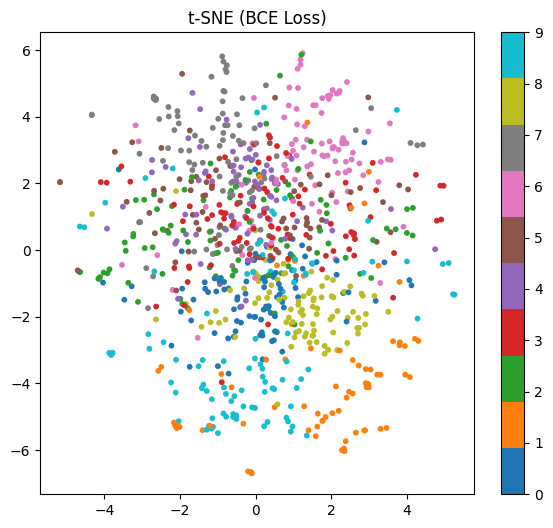

In [18]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

features_bce, labels_bce = extract_features(
    model_vgg_bce, testloader
)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
bce_2d = tsne.fit_transform(features_bce)

plt.figure(figsize=(7,6))
plt.scatter(bce_2d[:,0], bce_2d[:,1],
            c=labels_bce, cmap="tab10", s=10)
plt.title("t-SNE (BCE Loss)")
plt.colorbar()
plt.show()

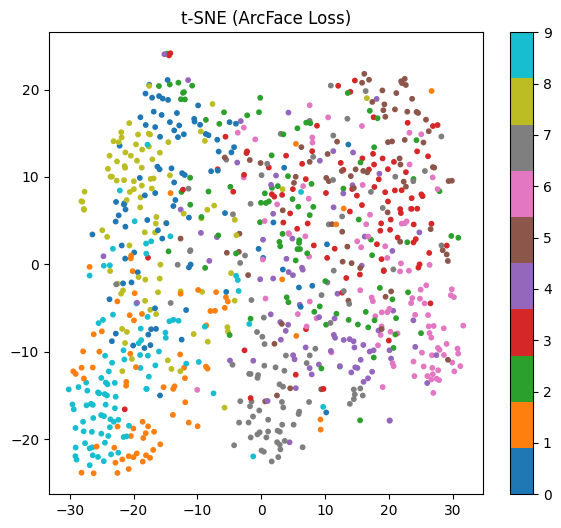

In [19]:
features_arc, labels_arc = extract_features(
    model_res_arc, testloader
)

tsne = TSNE(n_components=2, perplexity=30)
arc_2d = tsne.fit_transform(features_arc)

plt.figure(figsize=(7,6))
plt.scatter(arc_2d[:,0], arc_2d[:,1],
            c=labels_arc, cmap="tab10", s=10)
plt.title("t-SNE (ArcFace Loss)")
plt.colorbar()
plt.show()